# Experiment 2 (Other Approaches) — X Chromosome: Sub-Population Classification

**Goal:** Improve on the original Experiment 2 accuracy (SVM: 54.49%) for 26 sub-population classification.

**Improvements applied:**
1. **More PCA components** — 100 PCs instead of 50 (26 classes need more dimensions)
2. **Additional classifiers** — XGBoost, MLP (Neural Net), LDA added alongside original 5
3. **Hierarchical Classification** — Stage 1: predict super-pop (5 classes), Stage 2: predict sub-pop within each super-pop
4. **UMAP features** — Non-linear dimensionality reduction on top of PCA, then classify
5. **K-Means** — Evaluated on both PCA and UMAP feature spaces

**Baseline (Exp 2 original):** SVM 54.49% | K-Means ARI 0.2077

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import torch
import time

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, normalized_mutual_info_score
)
import xgboost as xgb
import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE     = "/Users/aaditya/VS Code/1000 genome project"
CSV_PATH = f"{BASE}/Data/chrX_full.csv"
QC_PATH  = f"{BASE}/Code/chrX_variant_summary_qc.csv"
PANEL    = f"{BASE}/integrated_call_samples_v3.20130502.ALL.panel"
OUT_DIR  = f"{BASE}/Output /"

device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f"Using device : {device}")
print("Imports OK")

Using device : mps
Imports OK


## 1. Load Panel, QC Variant List & Detect Sample Columns

In [2]:
# ── Population panel ───────────────────────────────────────────────────────
panel_full = pd.read_csv(PANEL, sep='\t', usecols=['sample', 'pop', 'super_pop', 'gender'])
sex_map    = panel_full.set_index('sample')['gender'].to_dict()

print(f"Panel samples : {len(panel_full):,}")
print(panel_full['super_pop'].value_counts())

# ── QC-passed variant positions ────────────────────────────────────────────
vs_clean = pd.read_csv(QC_PATH, usecols=['POS'])
qc_pos   = set(vs_clean['POS'].astype(str).values)
print(f"\nQC-passed variants : {len(qc_pos):,}")

# ── Detect sample columns from CSV header ─────────────────────────────────
META_COLS   = {'#CHROM','CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT'}
header      = pd.read_csv(CSV_PATH, nrows=0, low_memory=False)
header.columns = [c.strip().lstrip('\ufeff') for c in header.columns]
panel_samples  = set(panel_full['sample'].values)
sample_cols    = [c for c in header.columns if c not in META_COLS and c in panel_samples]
sample_arr     = np.array(sample_cols)
is_male        = np.array([sex_map.get(s, 'female') == 'male' for s in sample_cols])
n_samples      = len(sample_cols)

print(f"\nSamples in matrix : {n_samples:,}")
print(f"Males : {is_male.sum():,} | Females : {(~is_male).sum():,}")

Panel samples : 2,504
super_pop
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64

QC-passed variants : 3,434,403

Samples in matrix : 2,504
Males : 1,233 | Females : 1,271


## 2. Incremental Gram-Matrix PCA — 100 Components (All 3.4M Variants, MPS GPU)

**Improvement 1:** Using 100 PCA components instead of 50. With 26 sub-population classes, more components retain finer genetic structure needed for sub-population separation.

In [3]:
GT_FEMALE = {'0|0':0.0,'0/0':0.0,'0|1':0.5,'1|0':0.5,'0/1':0.5,'1/0':0.5,
             '1|1':1.0,'1/1':1.0,'.':np.nan,'.|.':np.nan,'./.':np.nan}
GT_MALE   = {'0':0.0,'1':1.0,'.':np.nan}

def parse_gt(val, male):
    s = str(val).split(':')[0]
    return GT_MALE.get(s, GT_FEMALE.get(s, np.nan)) if male else GT_FEMALE.get(s, np.nan)

CHUNK_SIZE   = 50_000
N_COMPONENTS = 100   # ← increased from 50 to 100

col_sum   = np.zeros(n_samples, dtype=np.float64)
col_count = np.zeros(n_samples, dtype=np.float64)
G_cpu     = np.zeros((n_samples, n_samples), dtype=np.float64)

t0 = time.time()
chunks_processed = 0
variants_used    = 0

print("Computing Gram matrix G = X X^T over all QC-passed variants...")
print(f"PCA components: {N_COMPONENTS} (vs 50 in original Exp 2)\n")

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, dtype=str):
    chunk.columns = [c.strip().lstrip('\ufeff') for c in chunk.columns]
    pos_col = 'POS' if 'POS' in chunk.columns else chunk.columns[1]
    mask    = chunk[pos_col].astype(str).isin(qc_pos)
    chunk   = chunk[mask]
    if chunk.empty:
        continue

    present = [c for c in sample_cols if c in chunk.columns]
    if not present:
        continue

    G_chunk = np.full((len(chunk), n_samples), np.nan, dtype=np.float32)
    for j, col in enumerate(sample_cols):
        if col not in chunk.columns:
            continue
        male = bool(is_male[j])
        G_chunk[:, j] = [parse_gt(v, male) for v in chunk[col].values]

    col_means = np.nanmean(G_chunk, axis=1, keepdims=True)
    nan_mask  = np.isnan(G_chunk)
    G_chunk[nan_mask] = np.take(col_means.squeeze(), np.where(nan_mask)[0])

    col_sum   += G_chunk.sum(axis=0)
    col_count += G_chunk.shape[0]

    t_chunk = torch.tensor(G_chunk, dtype=torch.float32, device=device)
    G_cpu  += (t_chunk.T @ t_chunk).cpu().numpy().astype(np.float64)

    variants_used    += len(chunk)
    chunks_processed += 1

    if chunks_processed % 10 == 0:
        elapsed = time.time() - t0
        print(f"  Chunk {chunks_processed:>4} | Variants used: {variants_used:>9,} | "
              f"Elapsed: {elapsed/60:.1f} min", flush=True)

print(f"\nDone. {variants_used:,} variants processed in {(time.time()-t0)/60:.1f} min")

Computing Gram matrix G = X X^T over all QC-passed variants...
PCA components: 100 (vs 50 in original Exp 2)

  Chunk   10 | Variants used:   496,660 | Elapsed: 10.3 min
  Chunk   20 | Variants used:   993,996 | Elapsed: 20.3 min
  Chunk   30 | Variants used: 1,491,353 | Elapsed: 30.2 min
  Chunk   40 | Variants used: 1,988,896 | Elapsed: 40.2 min
  Chunk   50 | Variants used: 2,486,351 | Elapsed: 50.2 min
  Chunk   60 | Variants used: 2,983,691 | Elapsed: 60.4 min
  Chunk   70 | Variants used: 3,449,249 | Elapsed: 69.9 min

Done. 3,449,249 variants processed in 69.9 min


Running eigendecomposition on Gram matrix (2504×2504)...
Eigendecomposition done in 0.6s
PCA matrix shape: (2504, 100)

Variance explained:
  PC1–PC10  : 63.29%
  PC1–PC50  : 66.66%
  PC1–PC100 : 69.53%


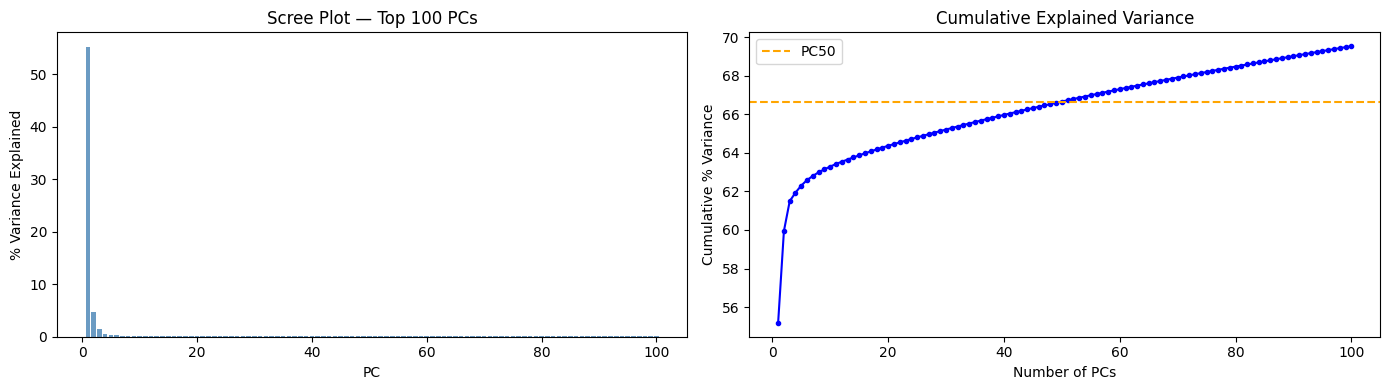

In [4]:
# ── Centre & eigendecompose the Gram matrix ───────────────────────────────
mu        = col_sum / col_count
n_var     = float(variants_used)
G_centred = G_cpu - n_var * np.outer(mu, mu)

print("Running eigendecomposition on Gram matrix (2504×2504)...")
t1 = time.time()

eigenvalues, eigenvectors = np.linalg.eigh(G_centred)
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]
eigenvalues  = eigenvalues[:N_COMPONENTS]
eigenvectors = eigenvectors[:, :N_COMPONENTS]

print(f"Eigendecomposition done in {time.time()-t1:.1f}s")

X_pca = eigenvectors * np.sqrt(np.maximum(eigenvalues, 0))
print(f"PCA matrix shape: {X_pca.shape}")

# Explained variance
all_eigs = np.linalg.eigvalsh(G_centred)[::-1]
exp_var  = eigenvalues / all_eigs[all_eigs > 0].sum() * 100
print(f"\nVariance explained:")
print(f"  PC1–PC10  : {exp_var[:10].sum():.2f}%")
print(f"  PC1–PC50  : {exp_var[:50].sum():.2f}%")
print(f"  PC1–PC100 : {exp_var[:100].sum():.2f}%")

# Scree plot — top 100 PCs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1, 101), exp_var, color='steelblue', alpha=0.8)
axes[0].set_xlabel('PC'); axes[0].set_ylabel('% Variance Explained')
axes[0].set_title('Scree Plot — Top 100 PCs')
axes[1].plot(range(1, 101), np.cumsum(exp_var), 'bo-', markersize=3)
axes[1].axhline(y=np.cumsum(exp_var)[49], color='orange', linestyle='--', label='PC50')
axes[1].set_xlabel('Number of PCs'); axes[1].set_ylabel('Cumulative % Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_other_scree.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Load Sub-Population Labels & Visualise PCA

Sub-population classes (26): ['ACB' 'ASW' 'BEB' 'CDX' 'CEU' 'CHB' 'CHS' 'CLM' 'ESN' 'FIN' 'GBR' 'GIH'
 'GWD' 'IBS' 'ITU' 'JPT' 'KHV' 'LWK' 'MSL' 'MXL' 'PEL' 'PJL' 'PUR' 'STU'
 'TSI' 'YRI']

Sub-population distribution:
  ACB    :   96
  ASW    :   61
  BEB    :   86
  CDX    :   93
  CEU    :   99
  CHB    :  103
  CHS    :  105
  CLM    :   94
  ESN    :   99
  FIN    :   99
  GBR    :   91
  GIH    :  103
  GWD    :  113
  IBS    :  107
  ITU    :  102
  JPT    :  104
  KHV    :   99
  LWK    :   99
  MSL    :   85
  MXL    :   64
  PEL    :   85
  PJL    :   96
  PUR    :  104
  STU    :  102
  TSI    :  107
  YRI    :  108


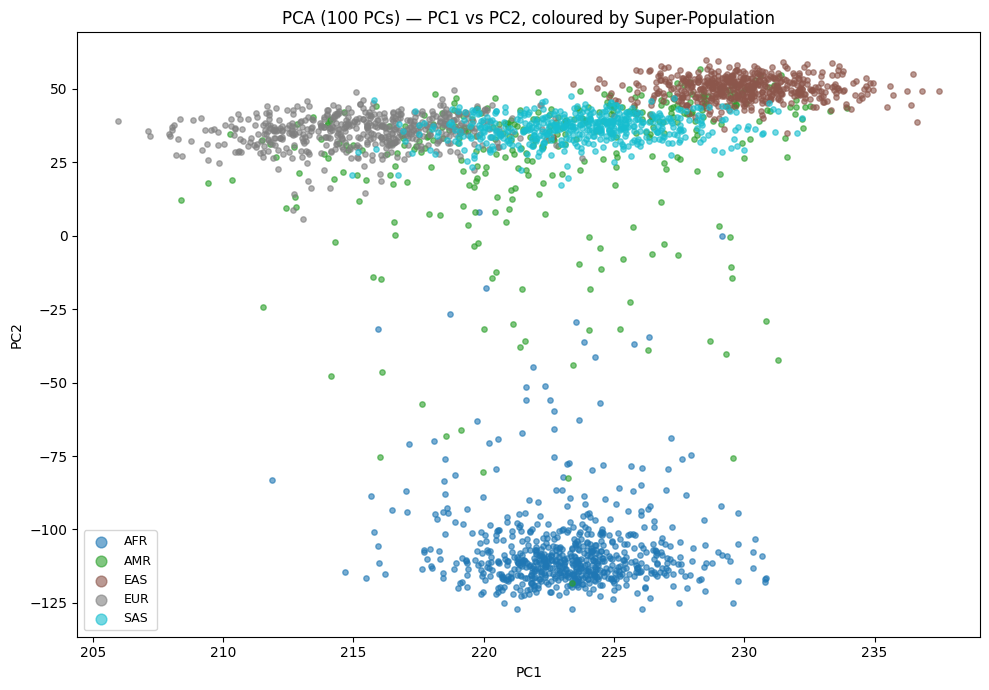

In [5]:
panel = panel_full[panel_full['sample'].isin(sample_arr)].set_index('sample').loc[sample_arr]

y_str     = np.array(panel['pop'].values)        # 26 sub-populations
super_str = np.array(panel['super_pop'].values)  # 5 super-pops
N_POPS    = len(np.unique(y_str))

le_sub   = LabelEncoder()
le_super = LabelEncoder()
y        = le_sub.fit_transform(y_str)
y_super  = le_super.fit_transform(super_str)

print(f"Sub-population classes ({N_POPS}): {le_sub.classes_}")
print(f"\nSub-population distribution:")
for pop, cnt in zip(*np.unique(y_str, return_counts=True)):
    print(f"  {pop:<6} : {cnt:>4}")

# PC1 vs PC2 scatter coloured by super-pop
super_pops  = np.unique(super_str)
colors_spop = cm.tab10(np.linspace(0, 1, len(super_pops)))
fig, ax = plt.subplots(figsize=(10, 7))
for i, sp in enumerate(super_pops):
    mask = super_str == sp
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors_spop[i]],
               label=sp, alpha=0.6, s=15)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PCA (100 PCs) — PC1 vs PC2, coloured by Super-Population')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_other_pca_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. UMAP Dimensionality Reduction on PCA Features

**Improvement 4:** PCA is linear — it misses non-linear population structure. UMAP captures the hierarchical "tree" of populations and can separate sub-populations that overlap in PCA space.

In [6]:
print("Running UMAP on top of 100 PCA components...")
t_umap = time.time()

reducer = umap.UMAP(
    n_components=50,      # 50 UMAP dims for classification (not just 2D viz)
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',
    random_state=RANDOM_STATE,
    verbose=True
)
X_umap = reducer.fit_transform(X_pca)
print(f"\nUMAP done in {(time.time()-t_umap)/60:.1f} min")
print(f"UMAP matrix shape: {X_umap.shape}")

# Also compute 2D UMAP for visualization
print("\nComputing 2D UMAP for visualization...")
reducer_2d = umap.UMAP(
    n_components=2, n_neighbors=30, min_dist=0.1,
    metric='euclidean', random_state=RANDOM_STATE
)
X_umap_2d = reducer_2d.fit_transform(X_pca)
print("2D UMAP done")

Running UMAP on top of 100 PCA components...
UMAP(n_components=50, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Apr 14 14:52:58 2026 Construct fuzzy simplicial set
Tue Apr 14 14:52:59 2026 Finding Nearest Neighbors
Tue Apr 14 14:53:01 2026 Finished Nearest Neighbor Search
Tue Apr 14 14:53:02 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Apr 14 14:53:05 2026 Finished embedding

UMAP done in 0.1 min
UMAP matrix shape: (2504, 50)

Computing 2D UMAP for visualization...
2D UMAP done


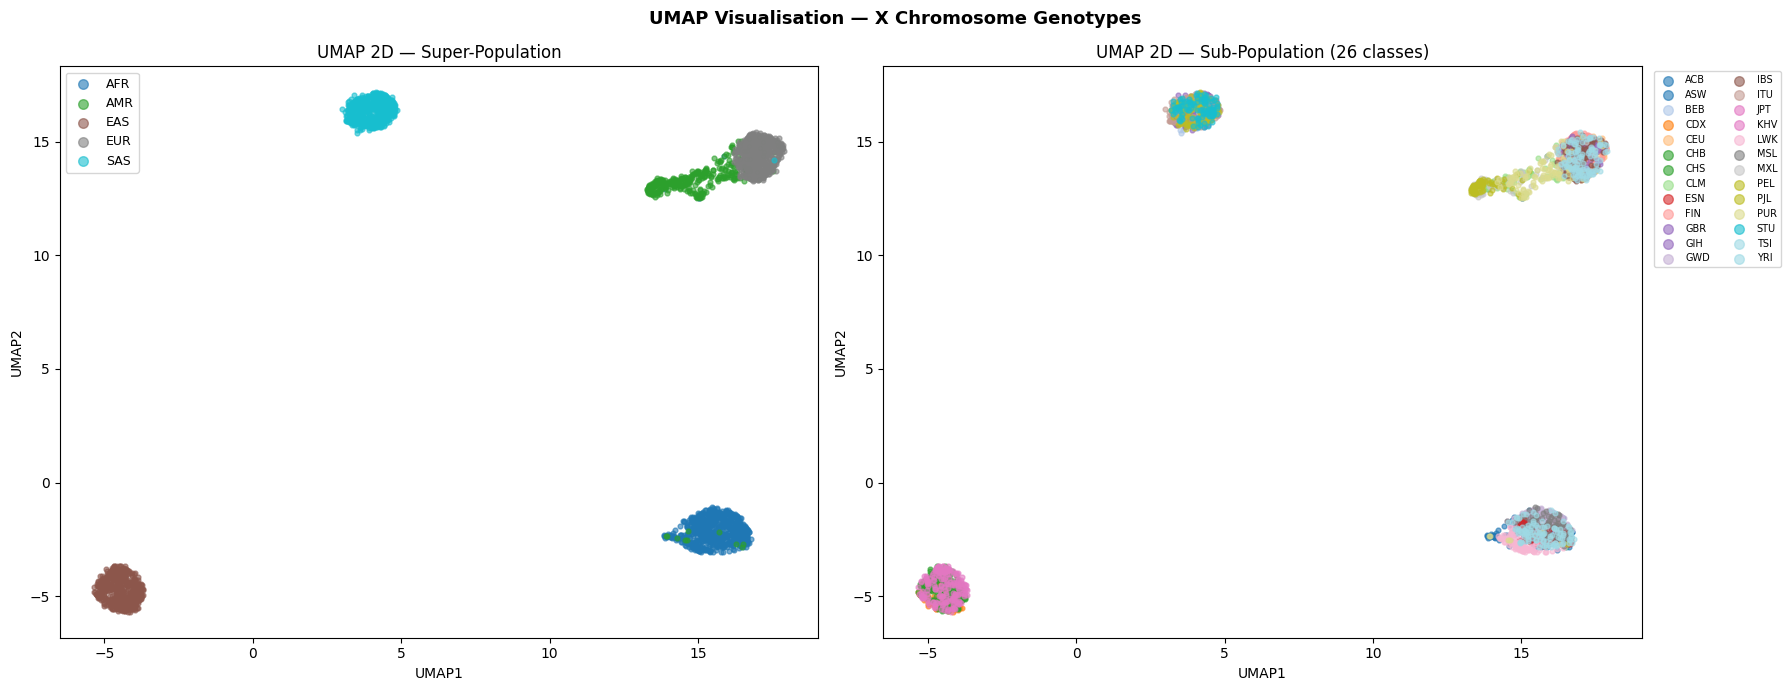

In [7]:
# Visualise 2D UMAP — coloured by super-pop and sub-pop
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: super-pop
for i, sp in enumerate(super_pops):
    mask = super_str == sp
    axes[0].scatter(X_umap_2d[mask, 0], X_umap_2d[mask, 1],
                    c=[colors_spop[i]], label=sp, alpha=0.6, s=12)
axes[0].set_title('UMAP 2D — Super-Population')
axes[0].set_xlabel('UMAP1'); axes[0].set_ylabel('UMAP2')
axes[0].legend(markerscale=2, fontsize=9)

# Right: sub-pop (26 classes)
sub_pops  = np.unique(y_str)
colors_sub = cm.tab20(np.linspace(0, 1, len(sub_pops)))
for i, sp in enumerate(sub_pops):
    mask = y_str == sp
    axes[1].scatter(X_umap_2d[mask, 0], X_umap_2d[mask, 1],
                    c=[colors_sub[i]], label=sp, alpha=0.6, s=12)
axes[1].set_title('UMAP 2D — Sub-Population (26 classes)')
axes[1].set_xlabel('UMAP1'); axes[1].set_ylabel('UMAP2')
axes[1].legend(markerscale=2, fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('UMAP Visualisation — X Chromosome Genotypes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_other_umap_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Approach A — Standard Classifiers on 100 PCA Components

**Improvements:** 100 PCs + additional classifiers: XGBoost, MLP (Neural Net), LDA

In [8]:
X_train_pca, X_test_pca, y_train, y_test, y_train_str, y_test_str = train_test_split(
    X_pca, np.array(y), np.array(y_str),
    test_size=0.2, stratify=np.array(y), random_state=RANDOM_STATE
)
print(f"Train: {X_train_pca.shape[0]} samples | Test: {X_test_pca.shape[0]} samples")
print(f"Features (PCA): {X_train_pca.shape[1]} | Classes: {N_POPS}")

classifiers_pca = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, solver='lbfgs', C=1.0, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(
        kernel='rbf', C=10, gamma='scale',
        decision_function_shape='ovo', random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(
        n_neighbors=7, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), max_iter=500,
        learning_rate_init=0.001, random_state=RANDOM_STATE),
    "LDA": LinearDiscriminantAnalysis(
        solver='svd', n_components=25),
}

results_pca    = []
trained_pca    = {}

for name, clf in classifiers_pca.items():
    t0 = time.time()
    cv_scores = cross_val_score(clf, X_train_pca, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    test_acc = accuracy_score(y_test, y_pred)
    elapsed = time.time() - t0
    trained_pca[name] = clf
    results_pca.append({
        'Model': name, 'Test Accuracy': test_acc,
        'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std(),
        'Time (s)': elapsed
    })
    print(f"  {name:<22} | Test: {test_acc:.4f} | CV: {cv_scores.mean():.4f}±{cv_scores.std():.4f} | {elapsed:.0f}s")

results_pca_df = pd.DataFrame(results_pca).sort_values('Test Accuracy', ascending=False)
print(f"\n=== Approach A — 100 PCA Components ===")
print(results_pca_df.to_string(index=False))

Train: 2003 samples | Test: 501 samples
Features (PCA): 100 | Classes: 26
  Logistic Regression    | Test: 0.5090 | CV: 0.4843±0.0222 | 4s
  SVM (RBF)              | Test: 0.5449 | CV: 0.5482±0.0115 | 2s
  Random Forest          | Test: 0.4910 | CV: 0.4613±0.0157 | 2s
  Decision Tree          | Test: 0.3174 | CV: 0.2821±0.0282 | 2s
  KNN                    | Test: 0.4311 | CV: 0.3899±0.0170 | 0s
  XGBoost                | Test: 0.4651 | CV: 0.4708±0.0101 | 16s
  MLP                    | Test: 0.4970 | CV: 0.4823±0.0117 | 3s
  LDA                    | Test: 0.5669 | CV: 0.5666±0.0137 | 0s

=== Approach A — 100 PCA Components ===
              Model  Test Accuracy  CV Mean   CV Std  Time (s)
                LDA       0.566866 0.566643 0.013660  0.163193
          SVM (RBF)       0.544910 0.548172 0.011497  1.613956
Logistic Regression       0.508982 0.484293 0.022233  3.824901
                MLP       0.497006 0.482281 0.011676  3.362374
      Random Forest       0.491018 0.461300 0.015

## 6. Approach B — Classifiers on UMAP Features

**Improvement 4:** UMAP captures non-linear population structure. Classify on 50-dim UMAP embedding.

In [9]:
X_train_umap, X_test_umap, _, _ = train_test_split(
    X_umap, np.array(y),
    test_size=0.2, stratify=np.array(y), random_state=RANDOM_STATE
)
print(f"Train: {X_train_umap.shape[0]} samples | Test: {X_test_umap.shape[0]} samples")
print(f"Features (UMAP): {X_train_umap.shape[1]} | Classes: {N_POPS}")

classifiers_umap = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, solver='lbfgs', C=1.0, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(
        kernel='rbf', C=10, gamma='scale',
        decision_function_shape='ovo', random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), max_iter=500,
        learning_rate_init=0.001, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}

results_umap  = []
trained_umap  = {}

for name, clf in classifiers_umap.items():
    t0 = time.time()
    cv_scores = cross_val_score(clf, X_train_umap, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train_umap, y_train)
    y_pred = clf.predict(X_test_umap)
    test_acc = accuracy_score(y_test, y_pred)
    elapsed = time.time() - t0
    trained_umap[name] = clf
    results_umap.append({
        'Model': name, 'Test Accuracy': test_acc,
        'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std(),
        'Time (s)': elapsed
    })
    print(f"  {name:<22} | Test: {test_acc:.4f} | CV: {cv_scores.mean():.4f}±{cv_scores.std():.4f} | {elapsed:.0f}s")

results_umap_df = pd.DataFrame(results_umap).sort_values('Test Accuracy', ascending=False)
print(f"\n=== Approach B — UMAP (50-dim) Features ===")
print(results_umap_df.to_string(index=False))

Train: 2003 samples | Test: 501 samples
Features (UMAP): 50 | Classes: 26
  Logistic Regression    | Test: 0.4212 | CV: 0.4104±0.0235 | 1s
  SVM (RBF)              | Test: 0.3932 | CV: 0.3669±0.0058 | 0s
  Random Forest          | Test: 0.4491 | CV: 0.4219±0.0146 | 1s
  XGBoost                | Test: 0.4531 | CV: 0.4064±0.0185 | 12s
  MLP                    | Test: 0.2076 | CV: 0.1977±0.0196 | 1s
  KNN                    | Test: 0.4232 | CV: 0.4029±0.0151 | 0s

=== Approach B — UMAP (50-dim) Features ===
              Model  Test Accuracy  CV Mean   CV Std  Time (s)
            XGBoost       0.453094 0.406377 0.018524 12.399608
      Random Forest       0.449102 0.421857 0.014593  0.809154
                KNN       0.423154 0.402884 0.015119  0.030985
Logistic Regression       0.421158 0.410362 0.023471  0.793255
          SVM (RBF)       0.393214 0.366948 0.005767  0.157110
                MLP       0.207585 0.197681 0.019586  0.821720


## 7. Approach C — Hierarchical Classification

**Improvement 3 (Most Impactful):** Instead of classifying all 26 sub-populations at once:
- **Stage 1:** Predict super-population (5 classes → expected ~99% accuracy)
- **Stage 2:** For each predicted super-pop, predict sub-population within that group only (5–7 classes per group)

This avoids cross-continent confusion (e.g., misclassifying a West African as East Asian is impossible).

In [10]:
# ── Stage 1: Super-population classifier ──────────────────────────────────
print("=" * 60)
print("STAGE 1 — Super-Population Classification (5 classes)")
print("=" * 60)

# Split using same indices as PCA approach
indices = np.arange(len(y))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, stratify=np.array(y), random_state=RANDOM_STATE
)

X_tr = X_pca[idx_train]
X_te = X_pca[idx_test]
y_super_tr = super_str[idx_train]
y_super_te = super_str[idx_test]
y_sub_tr   = y_str[idx_train]
y_sub_te   = y_str[idx_test]

# Stage 1 classifier: SVM (best at Exp1)
stage1_clf = SVC(kernel='rbf', C=10, gamma='scale',
                 decision_function_shape='ovr', random_state=RANDOM_STATE)
stage1_cv  = cross_val_score(stage1_clf, X_tr, y_super_tr, cv=5, scoring='accuracy')
stage1_clf.fit(X_tr, y_super_tr)

y_super_pred_test  = stage1_clf.predict(X_te)
y_super_pred_train = stage1_clf.predict(X_tr)

stage1_acc = accuracy_score(y_super_te, y_super_pred_test)
print(f"Stage 1 (SVM) — Test Accuracy : {stage1_acc:.4f}")
print(f"Stage 1 (SVM) — CV Mean       : {stage1_cv.mean():.4f} ± {stage1_cv.std():.4f}")

# ── Stage 2: Sub-population classifier per super-pop ──────────────────────
print("\n" + "=" * 60)
print("STAGE 2 — Sub-Population Classification within each Super-Pop")
print("=" * 60)

# Train one SVM per super-population on training data only
stage2_clfs = {}
stage2_encoders = {}
unique_super = np.unique(super_str)

for sp in unique_super:
    mask_tr = y_super_tr == sp
    X_sp_tr = X_tr[mask_tr]
    y_sp_tr = y_sub_tr[mask_tr]
    unique_classes = np.unique(y_sp_tr)
    
    le_sp = LabelEncoder()
    y_enc = le_sp.fit_transform(y_sp_tr)
    stage2_encoders[sp] = le_sp
    
    clf_sp = SVC(kernel='rbf', C=10, gamma='scale',
                 decision_function_shape='ovr', random_state=RANDOM_STATE)
    clf_sp.fit(X_sp_tr, y_enc)
    stage2_clfs[sp] = clf_sp
    print(f"  {sp}: trained on {len(X_sp_tr)} samples, {len(unique_classes)} sub-pops: {list(unique_classes)}")

print("\nStage 2 models trained.")

STAGE 1 — Super-Population Classification (5 classes)
Stage 1 (SVM) — Test Accuracy : 0.9860
Stage 1 (SVM) — CV Mean       : 0.9850 ± 0.0032

STAGE 2 — Sub-Population Classification within each Super-Pop
  AFR: trained on 528 samples, 7 sub-pops: ['ACB', 'ASW', 'ESN', 'GWD', 'LWK', 'MSL', 'YRI']
  AMR: trained on 277 samples, 4 sub-pops: ['CLM', 'MXL', 'PEL', 'PUR']
  EAS: trained on 403 samples, 5 sub-pops: ['CDX', 'CHB', 'CHS', 'JPT', 'KHV']
  EUR: trained on 403 samples, 5 sub-pops: ['CEU', 'FIN', 'GBR', 'IBS', 'TSI']
  SAS: trained on 392 samples, 5 sub-pops: ['BEB', 'GIH', 'ITU', 'PJL', 'STU']

Stage 2 models trained.


HIERARCHICAL PIPELINE EVALUATION ON TEST SET

Hierarchical Pipeline — Test Accuracy : 0.5529
Original Exp 2 SVM baseline          : 0.5449
Improvement                           : +0.80%

Breakdown by true super-population:
  AFR: 0.6090  (133 test samples)
  AMR: 0.6000  (70 test samples)
  EAS: 0.5347  (101 test samples)
  EUR: 0.5200  (100 test samples)
  SAS: 0.4948  (97 test samples)


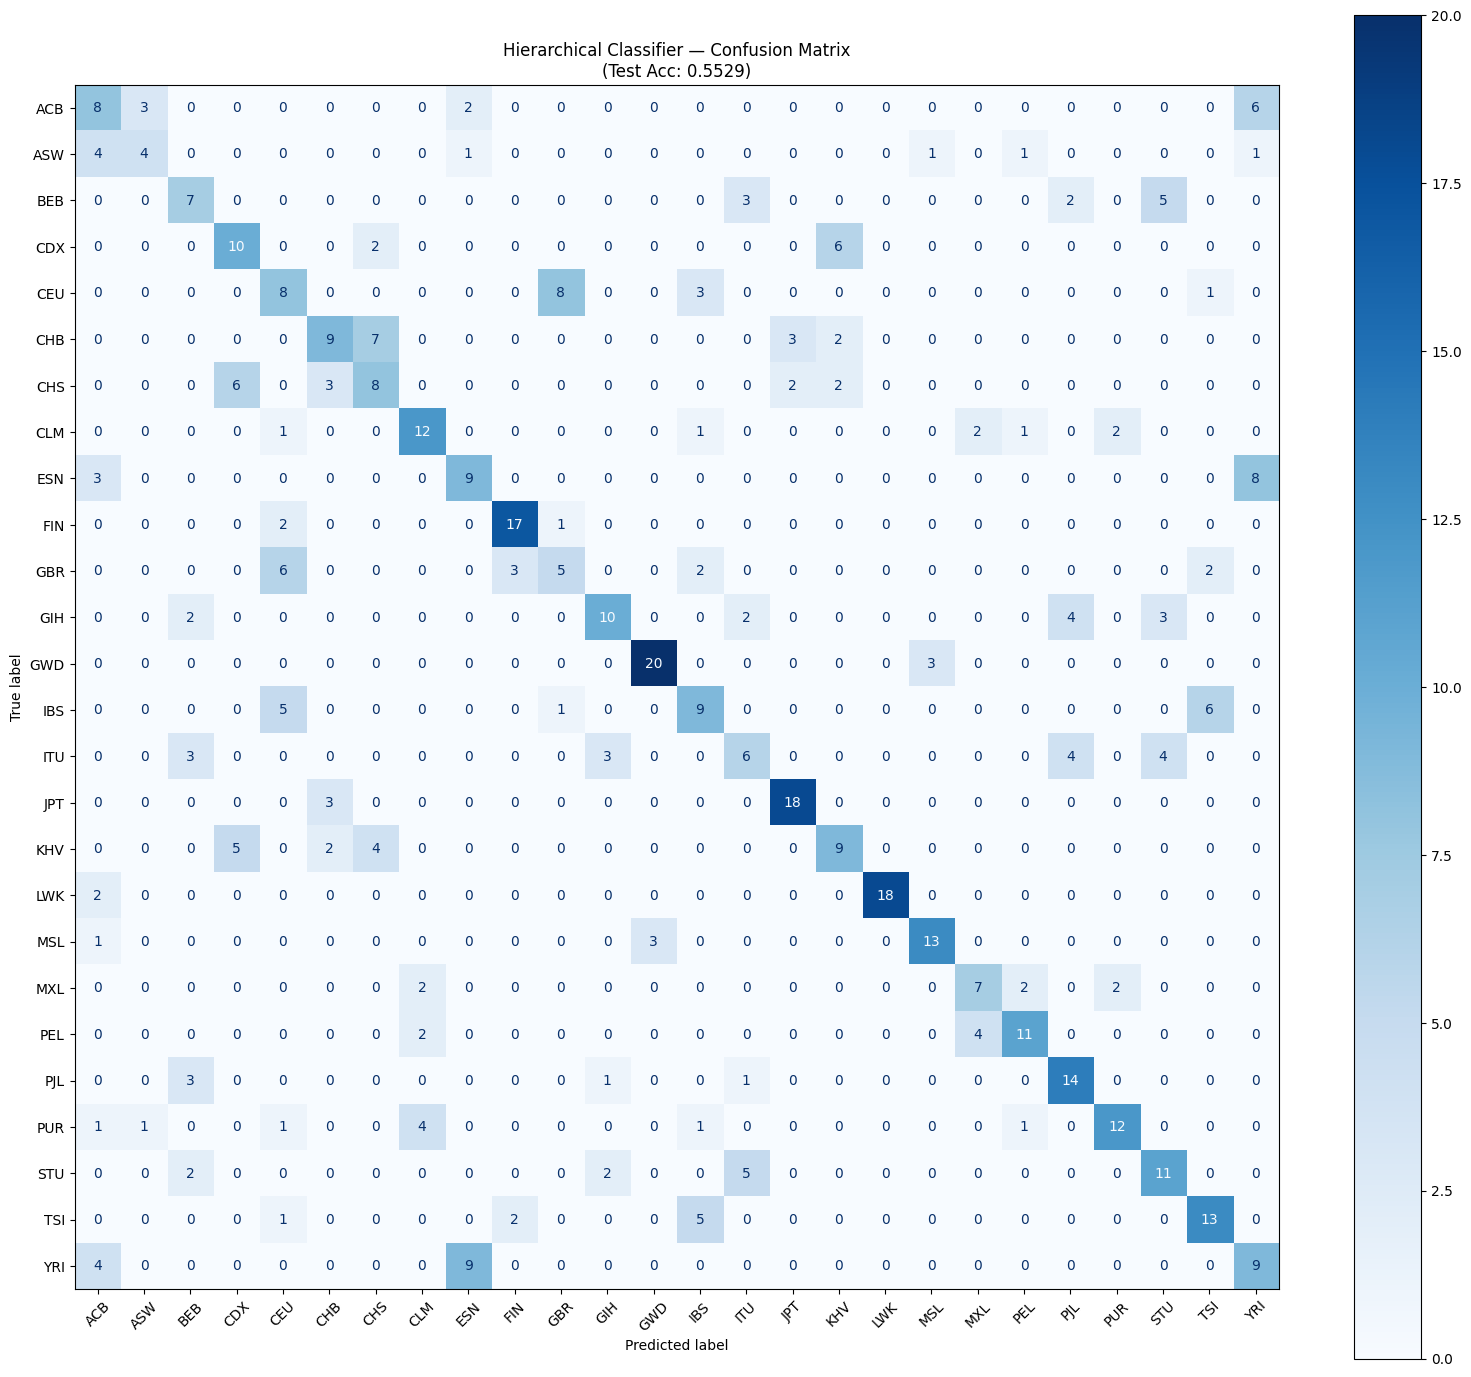


Per-class Report:
              precision    recall  f1-score   support

         ACB       0.35      0.42      0.38        19
         ASW       0.50      0.33      0.40        12
         BEB       0.41      0.41      0.41        17
         CDX       0.48      0.56      0.51        18
         CEU       0.33      0.40      0.36        20
         CHB       0.53      0.43      0.47        21
         CHS       0.38      0.38      0.38        21
         CLM       0.60      0.63      0.62        19
         ESN       0.43      0.45      0.44        20
         FIN       0.77      0.85      0.81        20
         GBR       0.33      0.28      0.30        18
         GIH       0.62      0.48      0.54        21
         GWD       0.87      0.87      0.87        23
         IBS       0.43      0.43      0.43        21
         ITU       0.35      0.30      0.32        20
         JPT       0.78      0.86      0.82        21
         KHV       0.47      0.45      0.46        20
        

In [11]:
# ── Evaluate Hierarchical Pipeline on Test Set ─────────────────────────────
print("=" * 60)
print("HIERARCHICAL PIPELINE EVALUATION ON TEST SET")
print("=" * 60)

y_hier_pred = []

for i in range(len(X_te)):
    # Stage 1: predict super-pop
    pred_super = y_super_pred_test[i]
    
    # Stage 2: predict sub-pop within that super-pop
    clf_sp = stage2_clfs[pred_super]
    le_sp  = stage2_encoders[pred_super]
    pred_encoded = clf_sp.predict(X_te[i:i+1])[0]
    pred_sub = le_sp.inverse_transform([pred_encoded])[0]
    y_hier_pred.append(pred_sub)

y_hier_pred = np.array(y_hier_pred)

hier_acc = accuracy_score(y_sub_te, y_hier_pred)
print(f"\nHierarchical Pipeline — Test Accuracy : {hier_acc:.4f}")
print(f"Original Exp 2 SVM baseline          : 0.5449")
print(f"Improvement                           : +{(hier_acc - 0.5449)*100:.2f}%")

# Per super-pop accuracy breakdown
print("\nBreakdown by true super-population:")
for sp in unique_super:
    mask = y_super_te == sp
    if mask.sum() == 0:
        continue
    acc_sp = accuracy_score(y_sub_te[mask], y_hier_pred[mask])
    print(f"  {sp}: {acc_sp:.4f}  ({mask.sum()} test samples)")

# Confusion matrix for hierarchical
cm_hier = confusion_matrix(y_sub_te, y_hier_pred, labels=le_sub.classes_)
fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hier, display_labels=le_sub.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f"Hierarchical Classifier — Confusion Matrix\n(Test Acc: {hier_acc:.4f})", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_other_hier_cm.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-class Report:")
print(classification_report(y_sub_te, y_hier_pred, labels=le_sub.classes_))

## 8. K-Means Clustering — PCA vs UMAP Feature Spaces

K-MEANS CLUSTERING COMPARISON
K-Means on 100 PCs   | ARI: 0.2129 | NMI: 0.5195
K-Means on UMAP (50d)| ARI: 0.2289 | NMI: 0.5372

Original Exp 2 (50 PCs) | ARI: 0.2077 | NMI: 0.5163


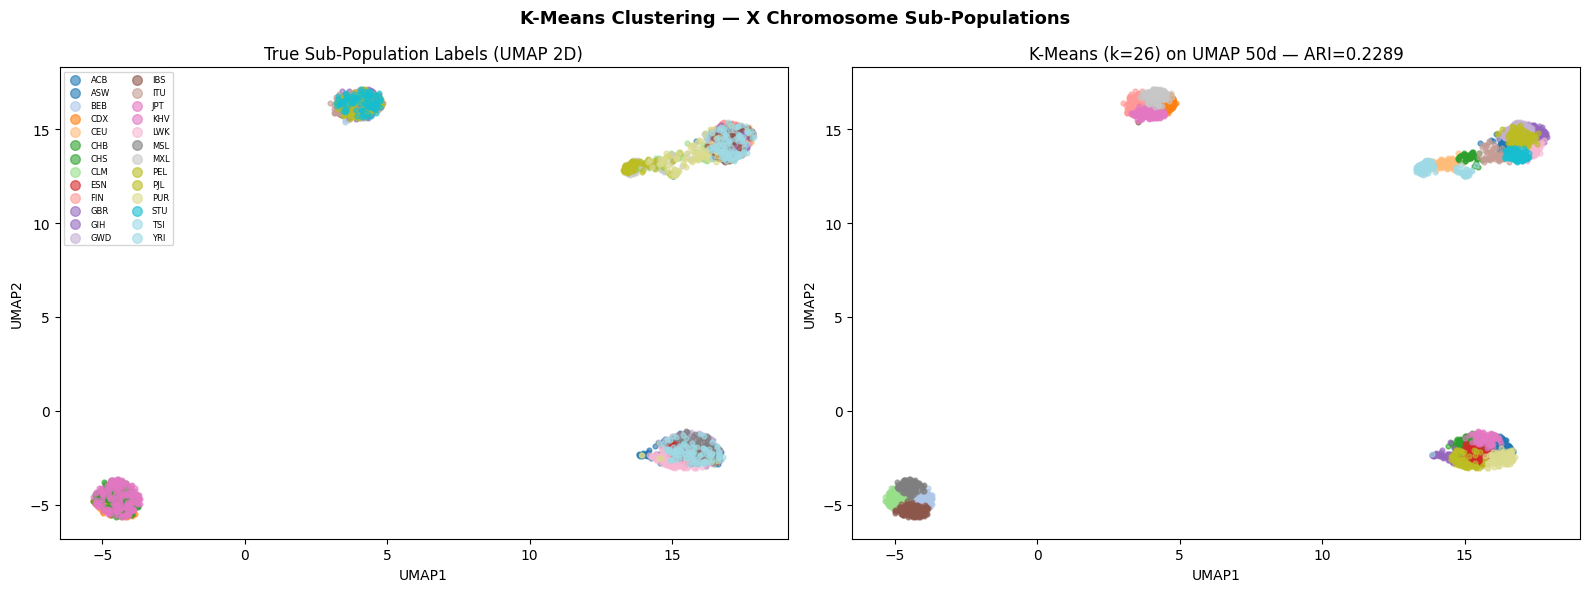

In [12]:
print("=" * 55)
print("K-MEANS CLUSTERING COMPARISON")
print("=" * 55)

# K-Means on 100-PC space
km_pca = KMeans(n_clusters=N_POPS, n_init=20, max_iter=500, random_state=RANDOM_STATE)
cl_pca = km_pca.fit_predict(X_pca)
ari_pca = adjusted_rand_score(y, cl_pca)
nmi_pca = normalized_mutual_info_score(y, cl_pca)
print(f"K-Means on 100 PCs   | ARI: {ari_pca:.4f} | NMI: {nmi_pca:.4f}")

# K-Means on UMAP space
km_umap = KMeans(n_clusters=N_POPS, n_init=20, max_iter=500, random_state=RANDOM_STATE)
cl_umap = km_umap.fit_predict(X_umap)
ari_umap = adjusted_rand_score(y, cl_umap)
nmi_umap = normalized_mutual_info_score(y, cl_umap)
print(f"K-Means on UMAP (50d)| ARI: {ari_umap:.4f} | NMI: {nmi_umap:.4f}")

print(f"\nOriginal Exp 2 (50 PCs) | ARI: 0.2077 | NMI: 0.5163")

# Visualise K-Means clusters on 2D UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# True labels
for i, sp in enumerate(sub_pops):
    mask = y_str == sp
    axes[0].scatter(X_umap_2d[mask, 0], X_umap_2d[mask, 1],
                    c=[colors_sub[i]], label=sp, alpha=0.6, s=12)
axes[0].set_title('True Sub-Population Labels (UMAP 2D)')
axes[0].set_xlabel('UMAP1'); axes[0].set_ylabel('UMAP2')
axes[0].legend(markerscale=2, fontsize=6, ncol=2)

# K-Means on UMAP clusters
colors_km = cm.tab20(np.linspace(0, 1, N_POPS))
for k in range(N_POPS):
    mask = cl_umap == k
    axes[1].scatter(X_umap_2d[mask, 0], X_umap_2d[mask, 1],
                    c=[colors_km[k]], alpha=0.6, s=12)
axes[1].set_title(f'K-Means (k=26) on UMAP 50d — ARI={ari_umap:.4f}')
axes[1].set_xlabel('UMAP1'); axes[1].set_ylabel('UMAP2')

plt.suptitle('K-Means Clustering — X Chromosome Sub-Populations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_other_kmeans_umap.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Comparison — All Approaches

FINAL COMPARISON — ALL APPROACHES (X Chromosome, 26 Sub-Pops)
                    Approach  Best Accuracy  K-Means ARI
Original Exp 2 (50 PCs, SVM)       0.544900     0.207700
            A: 100 PCs (LDA)       0.566866     0.212908
           B: UMAP (XGBoost)       0.453094     0.228888
   C: Hierarchical (SVM+SVM)       0.552894          NaN


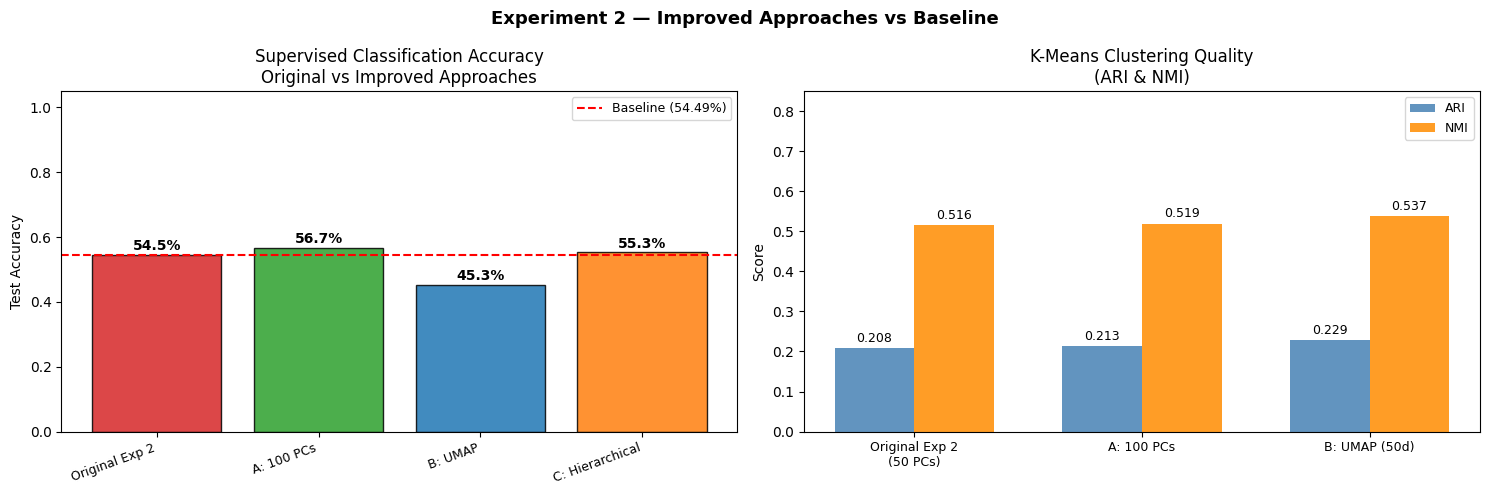

In [13]:
# ── Build comparison table ─────────────────────────────────────────────────
best_pca  = results_pca_df.iloc[0]
best_umap = results_umap_df.iloc[0]

comparison = pd.DataFrame([
    {'Approach': 'Original Exp 2 (50 PCs, SVM)',      'Best Accuracy': 0.5449, 'K-Means ARI': 0.2077},
    {'Approach': f'A: 100 PCs ({best_pca["Model"]})', 'Best Accuracy': best_pca['Test Accuracy'], 'K-Means ARI': ari_pca},
    {'Approach': f'B: UMAP ({best_umap["Model"]})',   'Best Accuracy': best_umap['Test Accuracy'], 'K-Means ARI': ari_umap},
    {'Approach': 'C: Hierarchical (SVM+SVM)',         'Best Accuracy': hier_acc, 'K-Means ARI': float('nan')},
])

print("=" * 65)
print("FINAL COMPARISON — ALL APPROACHES (X Chromosome, 26 Sub-Pops)")
print("=" * 65)
print(comparison.to_string(index=False))

# ── Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Supervised accuracy
ax = axes[0]
labels = comparison['Approach']
accs   = comparison['Best Accuracy']
colors_bar = ['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']
bars = ax.bar(range(len(labels)), accs, color=colors_bar, alpha=0.85, edgecolor='black')
ax.axhline(y=0.5449, color='red', linestyle='--', linewidth=1.5, label='Baseline (54.49%)')
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([l.split('(')[0].strip() for l in labels], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Test Accuracy')
ax.set_title('Supervised Classification Accuracy\nOriginal vs Improved Approaches')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

# K-Means ARI
ax2 = axes[1]
km_labels = ['Original Exp 2\n(50 PCs)', 'A: 100 PCs', 'B: UMAP (50d)']
km_aris   = [0.2077, ari_pca, ari_umap]
km_nmis   = [0.5163, nmi_pca, nmi_umap]
x = np.arange(len(km_labels))
w = 0.35
b1 = ax2.bar(x - w/2, km_aris, w, label='ARI', color='steelblue', alpha=0.85)
b2 = ax2.bar(x + w/2, km_nmis, w, label='NMI', color='darkorange', alpha=0.85)
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(km_labels, fontsize=9)
ax2.set_ylabel('Score')
ax2.set_title('K-Means Clustering Quality\n(ARI & NMI)')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 0.85)

plt.suptitle('Experiment 2 — Improved Approaches vs Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_other_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

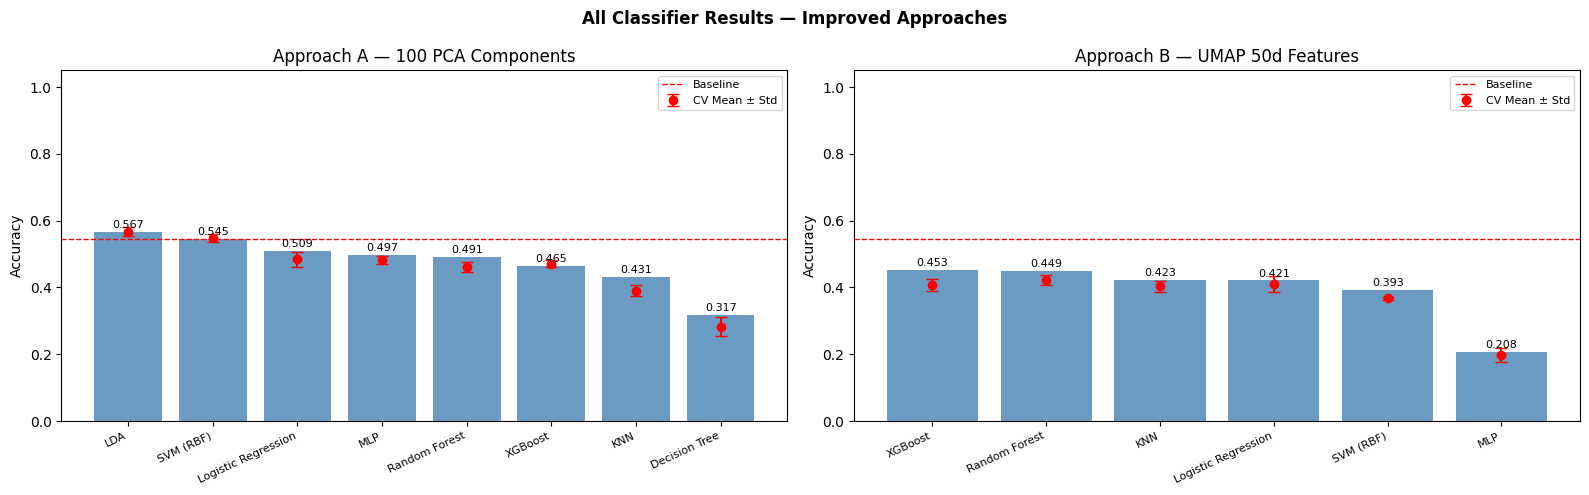

EXPERIMENT 2 (OTHER APPROACHES) — X CHROMOSOME FINAL SUMMARY

Dataset     : 2,504 samples | 3.4M variants | 100 PCs / 50 UMAP dims
Target      : 26 sub-populations
Baseline    : SVM 54.49% | K-Means ARI 0.2077

── APPROACH A: 100 PCA Components ──
  LDA                    0.5669  (CV 0.5666) | +2.20% vs baseline
  SVM (RBF)              0.5449  (CV 0.5482) | +0.00% vs baseline
  Logistic Regression    0.5090  (CV 0.4843) | -3.59% vs baseline
  MLP                    0.4970  (CV 0.4823) | -4.79% vs baseline
  Random Forest          0.4910  (CV 0.4613) | -5.39% vs baseline
  XGBoost                0.4651  (CV 0.4708) | -7.98% vs baseline
  KNN                    0.4311  (CV 0.3899) | -11.38% vs baseline
  Decision Tree          0.3174  (CV 0.2821) | -22.75% vs baseline

── APPROACH B: UMAP (50-dim) Features ──
  XGBoost                0.4531  (CV 0.4064) | -9.18% vs baseline
  Random Forest          0.4491  (CV 0.4219) | -9.58% vs baseline
  KNN                    0.4232  (CV 0.4029) | -

In [14]:
# ── Detailed model table for Approach A (100 PCs) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_i, (df, title) in enumerate([
    (results_pca_df,  'Approach A — 100 PCA Components'),
    (results_umap_df, 'Approach B — UMAP 50d Features'),
]):
    ax = axes[ax_i]
    x  = np.arange(len(df))
    bars = ax.bar(x, df['Test Accuracy'], color='steelblue', alpha=0.8)
    ax.errorbar(x, df['CV Mean'], yerr=df['CV Std'], fmt='ro', capsize=4, label='CV Mean ± Std')
    ax.axhline(y=0.5449, color='red', linestyle='--', linewidth=1, label='Baseline')
    for bar, v in zip(bars, df['Test Accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(df['Model'], rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

plt.suptitle('All Classifier Results — Improved Approaches', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}x_exp2_other_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Final printed summary ──────────────────────────────────────────────────
print("=" * 65)
print("EXPERIMENT 2 (OTHER APPROACHES) — X CHROMOSOME FINAL SUMMARY")
print("=" * 65)
print(f"\nDataset     : {X_pca.shape[0]:,} samples | 3.4M variants | 100 PCs / 50 UMAP dims")
print(f"Target      : {N_POPS} sub-populations")
print(f"Baseline    : SVM 54.49% | K-Means ARI 0.2077")

print("\n── APPROACH A: 100 PCA Components ──")
for _, row in results_pca_df.iterrows():
    delta = (row['Test Accuracy'] - 0.5449) * 100
    sign  = '+' if delta >= 0 else ''
    print(f"  {row['Model']:<22} {row['Test Accuracy']:.4f}  (CV {row['CV Mean']:.4f}) | {sign}{delta:.2f}% vs baseline")

print("\n── APPROACH B: UMAP (50-dim) Features ──")
for _, row in results_umap_df.iterrows():
    delta = (row['Test Accuracy'] - 0.5449) * 100
    sign  = '+' if delta >= 0 else ''
    print(f"  {row['Model']:<22} {row['Test Accuracy']:.4f}  (CV {row['CV Mean']:.4f}) | {sign}{delta:.2f}% vs baseline")

print("\n── APPROACH C: Hierarchical Classification ──")
delta_h = (hier_acc - 0.5449) * 100
sign_h  = '+' if delta_h >= 0 else ''
print(f"  Stage1 SVM (super-pop)  {stage1_acc:.4f}")
print(f"  Hierarchical Pipeline   {hier_acc:.4f}  | {sign_h}{delta_h:.2f}% vs baseline")

print("\n── K-MEANS CLUSTERING ──")
print(f"  50  PCs (baseline)    ARI: 0.2077 | NMI: 0.5163")
print(f"  100 PCs               ARI: {ari_pca:.4f} | NMI: {nmi_pca:.4f}")
print(f"  UMAP 50d              ARI: {ari_umap:.4f} | NMI: {nmi_umap:.4f}")